In [160]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка и обработка данных

In [ ]:
PATH = './../data/processed'
files = {
    'customer': 'customer_nodes_training.p', 
    'event': 'event_table_training.p', 
    'product': 'product_nodes_training.p'
}

## Таблица с пользователями

In [216]:
df_cus = pd.read_pickle(PATH + files['customer'])
df_cus.head(10)

,hash(customerId),yearOfBirth,isMale,shippingCountry,premier,salesPerCustomer,returnsPerCustomer,customerReturnRate,customerId_level_return_code_A,customerId_level_return_code_B,customerId_level_return_code_C,customerId_level_return_code_D,customerId_level_return_code_E,customerId_level_return_code_D,customerId_level_return_code_F,customerId_level_return_code_G,customerId_level_return_code_H,customerId_level_return_code_I,customerId_level_return_code_J,customerId_level_return_code_K,customerId_level_return_code_L,Country_A,Country_B,Country_C,Country_D,Country_E,Country_F,Country_G,Country_H,Country_I
1,1901128802,1992,0,Country_G,0,4,1,0.250000,0.0,0.00,0.0,0.000,0.0,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000,0.0,0,0,0,0,0,0,1,0,0
2,-1347052608,2004,0,Country_E,0,7,3,0.428571,0.0,0.00,0.0,0.000,0.0,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000,0.0,0,0,0,0,1,0,0,0,0
3,1968224587,1975,1,Country_C,0,9,1,0.111111,0.0,0.00,0.0,0.000,0.0,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000,0.0,0,0,1,0,0,0,0,0,0
4,101496816,1995,0,Country_G,0,28,22,0.785714,0.0,0.00,0.0,0.000,0.0,0.954545,0.0,0.045455,0.000000,0.000000,0.000000,0.000,0.0,0,0,0,0,0,0,1,0,0
5,-1490187487,2002,0,Country_E,0,12,10,0.833333,0.0,0.00,0.0,0.000,0.0,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000,0.0,0,0,0,0,1,0,0,0,0
6,1364422922,1993,0,Country_G,0,15,8,0.533333,0.0,0.25,0.0,0.125,0.0,0.250000,0.0,0.000000,0.000000,0.000000,0.375000,0.000,0.0,0,0,0,0,0,0,1,0,0
7,1113383523,1970,0,Country_E,1,12,2,0.166667,0.0,0.00,0.0,0.000,0.0,0.500000,0.0,0.000000,0.000000,0.500000,0.000000,0.000,0.0,0,0,0,0,1,0,0,0,0
8,1634696409,1994,0,Country_G,0,19,8,0.421053,0.0,0.25,0.0,0.000,0.0,0.000000,0.0,0.000000,0.000000,0.250000,0.125000,0.375,0.0,0,0,0,0,0,0,1,0,0
9,760931585,1999,0,Country_D,0,9,3,0.333333,0.0,0.00,0.0,0.000,0.0,0.000000,0.0,0.000000,0.333333,0.000000,0.666667,0.000,0.0,0,0,0,1,0,0,0,0,0
10,1828428555,1993,0,Country_E,0,26,23,0.884615,0.0,0.00,0.0,0.000,0.0,0.521739,0.0,0.000000,0.000000,0.217391,0.260870,0.000,0.0,0,0,0,0,1,0,0,0,0


In [217]:
df_cus.columns

Index(['hash(customerId)', 'yearOfBirth', 'isMale', 'shippingCountry',
       'premier', 'salesPerCustomer', 'returnsPerCustomer',
       'customerReturnRate', 'customerId_level_return_code_A',
       'customerId_level_return_code_B', 'customerId_level_return_code_C',
       'customerId_level_return_code_D', 'customerId_level_return_code_E',
       'customerId_level_return_code_D', 'customerId_level_return_code_F',
       'customerId_level_return_code_G', 'customerId_level_return_code_H',
       'customerId_level_return_code_I', 'customerId_level_return_code_J',
       'customerId_level_return_code_K', 'customerId_level_return_code_L',
       'Country_A', 'Country_B', 'Country_C', 'Country_D', 'Country_E',
       'Country_F', 'Country_G', 'Country_H', 'Country_I'],
      dtype='object')

Значение признаков: 

|Колонка                                                                         | Значение                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| ------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `hash(customerId)`                                                              | Анонимизированный (хешированный) идентификатор покупателя — используется вместо реального ID для приватности. Это уникальный ключ, позволяющий отличать клиентов.                                                                                                                                                                                                                                                                                                             |
| `yearOfBirth`                                                                   | Год рождения покупателя — одна из демографических фич (хоть и ограниченная, без полного возраста), может помочь учитывать возраст при возвратах.                                                                                                                                                                                                                                                                                                                              |
| `isMale`                                                                        | Пол покупателя: бинарный признак (например, 1 = мужчина, 0 = женщина) — демография. В статье упоминается, что «мужчины менее склонны возвращать» в корреляции.                                                                                                                                                                                                                                                                                                  |
| `shippingCountry`                                                               | Страна доставки / страна покупателя — код/категория, указывающая, из какой страны покупатель; влияет на поведение возвратов (логистика, культура, предпочтения). В статье: виртуальные country-ноды используются, и распределение возвратов различается по странам.                                                                                                                                                                                   |
| `premier`                                                                       | Признак «премиум-покупатель» или «премиум-аккаунт» (например, подписка, VIP-статус, loyal-customer).                                                                                                                                                                                                    |
| `salesPerCustomer`                                                              | Общее (или среднее) число продаж / покупок, совершённых этим клиентом — агрегированное: сколько товаров (или заказов) сделал покупатель за историю. Это даёт представление об активности клиента.                                                                                                                                                                                                                                                                             |
| `returnsPerCustomer`                                                            | Количество возвратов, сделанных этим клиентом — агрегированная статистика возвратов клиента за историю; показывает «склонность к возвратам».                                                                                                                                                                                                                                                                                                                                  |
| `customerReturnRate`                                                            | Вероятность возврата для данного клиента, рассчитанная на основе исторических данных — например, `returnsPerCustomer / salesPerCustomer`. Это «личная» метрика propensity к возвратам.                                                                                                                                                                                                                                                                                        |
| `customerId_level_return_code_A`, `..._return_code_B`, ..., `..._return_code_L` | Здесь, **ratio** столбцы, отражающие распределение **причин возврата** (return reasons) для данного клиента. В статье сказано, что «ratios of different return reasons» включены.   То есть, например, `return_code_A` может означать причину «не подошёл размер», `B` — «не понравился цвет», `C` — «качество», и т.п. Переменные с суффиксом *level* могут означать, что значение — доля возвратов клиента с этой причиной. |
| `Country_A`, `Country_B`, `Country_C`, ... , `Country_I`                        | one-hot / dummy / категориальные столбцы для **страны доставки**: при хешировании страны она может быть представлена как код (A, B, C ...), и для модели сделали dummy-кодирование: если `Country_D = 1`, значит клиент — из страны D. То же для `shippingCountry`. Это даёт численные признаки для страны клиента.                                                                                                                                                   |

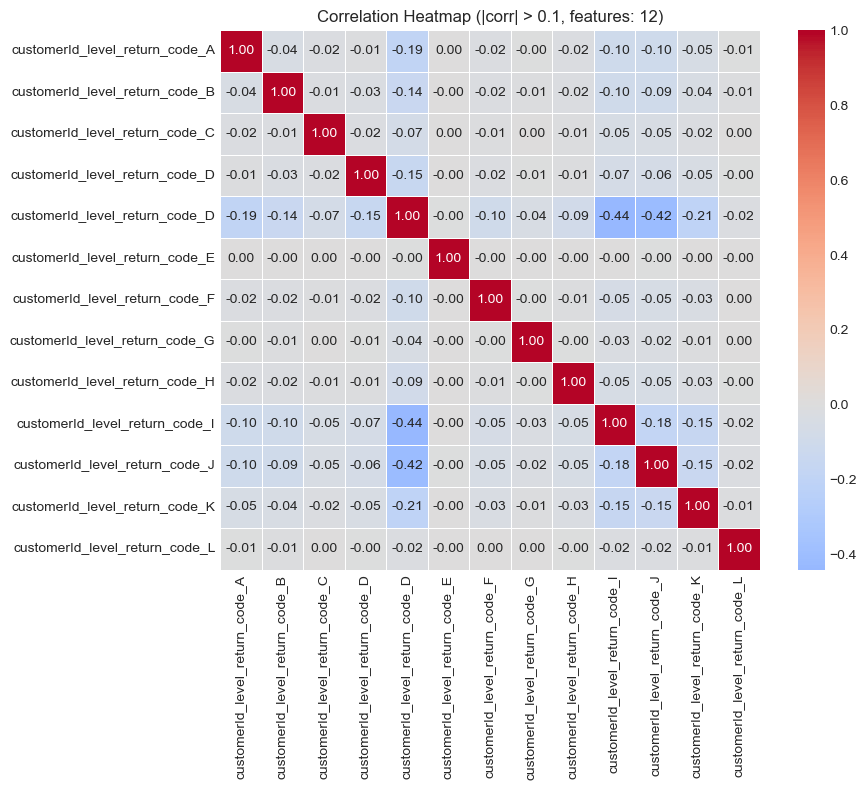

In [218]:
corr_cols = ['customerId_level_return_code_A', 'customerId_level_return_code_B', 
             'customerId_level_return_code_C', 'customerId_level_return_code_D', 
             'customerId_level_return_code_E', 'customerId_level_return_code_F',
             'customerId_level_return_code_G', 'customerId_level_return_code_H',
             'customerId_level_return_code_I', 'customerId_level_return_code_J',
             'customerId_level_return_code_K', 'customerId_level_return_code_L']

corr_matrix = df_cus[corr_cols].corr()
mask_series = (corr_matrix.abs() > 0.1).any(axis=0)
keep_mask = mask_series.tolist()
cols_to_keep = [col for col, keep in zip(corr_cols, keep_mask) if keep]

plt.figure(figsize=(10, 8))
sns.heatmap(df_cus[cols_to_keep].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=.5)
plt.title(f'Correlation Heatmap (|corr| > 0.1, features: {len(cols_to_keep)})')
plt.tight_layout()
plt.show()

In [219]:
# заменим one hot колонки на одну колонку Country
country_cols = [f'Country_{letter}' for letter in 'ABCDEFGHI']
df_cus['Country'] = df_cus[country_cols].idxmax(axis=1).str.replace('Country_', '')

In [220]:
df_cus['shippingCountry'] = df_cus['shippingCountry'].str.replace('Country_', '')

In [221]:
df_cus.drop(columns=country_cols, inplace=True)

In [222]:
df_cus.head()

,hash(customerId),yearOfBirth,isMale,shippingCountry,premier,salesPerCustomer,returnsPerCustomer,customerReturnRate,customerId_level_return_code_A,customerId_level_return_code_B,customerId_level_return_code_C,customerId_level_return_code_D,customerId_level_return_code_E,customerId_level_return_code_D,customerId_level_return_code_F,customerId_level_return_code_G,customerId_level_return_code_H,customerId_level_return_code_I,customerId_level_return_code_J,customerId_level_return_code_K,customerId_level_return_code_L,Country
1,1901128802,1992,0,G,0,4,1,0.250000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,G
2,-1347052608,2004,0,E,0,7,3,0.428571,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,E
3,1968224587,1975,1,C,0,9,1,0.111111,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,C
4,101496816,1995,0,G,0,28,22,0.785714,0.0,0.0,0.0,0.0,0.0,0.954545,0.0,0.045455,0.0,0.0,0.0,0.0,0.0,G
5,-1490187487,2002,0,E,0,12,10,0.833333,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,E


## Табличка с товарами

In [223]:
pd.set_option('display.max_columns', None)

df_prt = pd.read_pickle(PATH + files['product'])
df_prt.head(10)

,hash(variantID),hash(productID),productType,hash(supplierRef),brandDesc,avgGbpPrice,avgDiscountValue,salesPerProduct,returnsPerProduct,productReturnRate,variantID_level_return_code_A,variantID_level_return_code_B,variantID_level_return_code_C,variantID_level_return_code_D,variantID_level_return_code_E,variantID_level_return_code_D,variantID_level_return_code_F,variantID_level_return_code_G,variantID_level_return_code_H,variantID_level_return_code_I,variantID_level_return_code_J,variantID_level_return_code_K,variantID_level_return_code_L,Brand_A,Brand_B,Brand_C,Brand_D,Brand_E,Brand_F,Brand_G,Brand_I,Brand_J,Brand_K,productType_A,productType_B,productType_C,productType_D,productType_E,productType_F,productType_G,productType_H,productType_I,productType_J,productType_K
1,4550259741504178673,5879799799090574153,productType_B,221571216,Brand_K,27.61,18.17,18,7,0.388889,0.000000,0.000000,0.000000,0.000000,0.00,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
2,5340544183823383973,-5050515871057381912,productType_B,1012966519,Brand_K,34.61,14.83,18,12,0.666667,0.000000,0.083333,0.000000,0.083333,0.00,0.333333,0.000000,0.0,0.000000,0.250000,0.166667,0.083333,0.0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
3,7537628105862775507,-3809655638558592031,productType_B,-945781343,Brand_B,46.00,18.85,48,25,0.520833,0.000000,0.040000,0.040000,0.080000,0.04,0.360000,0.000000,0.0,0.000000,0.240000,0.160000,0.040000,0.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,4823898756921319393,3975857132452218008,productType_B,823422182,Brand_K,41.80,14.06,11,5,0.454545,0.000000,0.000000,0.000000,0.000000,0.00,0.600000,0.000000,0.0,0.000000,0.400000,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
5,-631800120190371126,-8518405539241061658,productType_B,-1601522830,Brand_J,27.59,16.30,114,86,0.754386,0.011628,0.093023,0.011628,0.069767,0.00,0.313953,0.000000,0.0,0.000000,0.174419,0.267442,0.058140,0.0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
6,7481083082656840757,-5445758009351463874,productType_B,1765115494,Brand_J,28.12,16.51,35,21,0.600000,0.000000,0.095238,0.000000,0.000000,0.00,0.380952,0.000000,0.0,0.000000,0.285714,0.142857,0.095238,0.0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
7,1152713539959922767,-3202217381398994721,productType_B,735180183,Brand_K,41.11,15.62,61,37,0.606557,0.000000,0.135135,0.000000,0.027027,0.00,0.540541,0.000000,0.0,0.027027,0.135135,0.054054,0.081081,0.0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
8,-3065166248260059873,2670181784277486938,productType_B,-558227089,Brand_K,22.22,18.89,19,6,0.315789,0.000000,0.000000,0.000000,0.166667,0.00,0.500000,0.000000,0.0,0.000000,0.166667,0.000000,0.166667,0.0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
9,-7194938454433361236,-2337716766507332743,productType_B,2073124536,Brand_K,68.60,13.81,127,70,0.551181,0.000000,0.042857,0.000000,0.014286,0.00,0.342857,0.042857,0.0,0.000000,0.014286,0.457143,0.085714,0.0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
10,-7536257844593590338,8234038229948675347,productType_B,241794201,Brand_B,27.76,16.27,15,8,0.533333,0.000000,0.000000,0.000000,0.125000,0.00,0.375000,0.000000,0.0,0.000000,0.250000,0.250000,0.000000,0.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [224]:
df_prt.brandDesc.nunique()

11

In [225]:
df_prt.columns

Index(['hash(variantID)', 'hash(productID)', 'productType',
       'hash(supplierRef)', 'brandDesc', 'avgGbpPrice', 'avgDiscountValue',
       'salesPerProduct', 'returnsPerProduct', 'productReturnRate',
       'variantID_level_return_code_A', 'variantID_level_return_code_B',
       'variantID_level_return_code_C', 'variantID_level_return_code_D',
       'variantID_level_return_code_E', 'variantID_level_return_code_D',
       'variantID_level_return_code_F', 'variantID_level_return_code_G',
       'variantID_level_return_code_H', 'variantID_level_return_code_I',
       'variantID_level_return_code_J', 'variantID_level_return_code_K',
       'variantID_level_return_code_L', 'Brand_A', 'Brand_B', 'Brand_C',
       'Brand_D', 'Brand_E', 'Brand_F', 'Brand_G', 'Brand_I', 'Brand_J',
       'Brand_K', 'productType_A', 'productType_B', 'productType_C',
       'productType_D', 'productType_E', 'productType_F', 'productType_G',
       'productType_H', 'productType_I', 'productType_J', 'productTy

Значение признаков:


| Колонка | Значение |
| :--- | :--- |
| **hash(variantID)** | Хешированный идентификатор варианта товара (SKU: конкретный размер/цвет/вариант). Уникален для варианта. |
| **hash(productID)** | Хешированный идентификатор «продукта» (группа вариантов — модель/артикул). Несколько variantID могут ссылаться на один productID. |
| **productType** | Читабельный тип/категория товара (короткая строка: например "Dress", "Shoes"). Есть и отдельное one-hot кодирование (productType_A..). |
| **hash(supplierRef)** | Хеш/идентификатор поставщика / поставки (supplier reference). Можно использовать для учета качества поставщика/логистики. |
| **brandDesc** | Название бренда (строка). Имеется соответствующее one-hot (Brand_A..). |
| **avgGbpPrice** | Средняя цена этого варианта в фунтах стерлингов (GBP). |
| **avgDiscountValue** | Среднее значение скидки на этот вариант. Приводится в %. |
| **salesPerProduct** | Количество продаж (агрегат) для продукта/варианта за период.|
| **returnsPerProduct** | Количество возвратов для этого продукта/варианта.  |
| **productReturnRate** | Доля возвратов у этого продукта: `returnsPerProduct / salesPerProduct`.  |
| **variantID_level_return_code_A ... variantID_level_return_code_L** | Доля (или частота) возвратов этого варианта по конкретным кодам причин возврата (A..L). Каждая буква — своя причина (A = размер, B = цвет и т.п.).  |
| **Brand_A ... Brand_K** | One-hot / dummy-кодирование бренда (категориальные признаки). Каждая колонка = 1, если `brandDesc` соответствует этому коду.  |
| **productType_A ... productType_K** | One-hot / dummy-кодирование типа/категории продукта. Аналогично Brand_*. |

In [226]:
brands = ['Brand_A', 'Brand_B', 'Brand_C',
          'Brand_D', 'Brand_E', 'Brand_F', 'Brand_G', 'Brand_I', 'Brand_J',
          'Brand_K']
product_types = ['productType_A', 'productType_B', 'productType_C',
          'productType_D', 'productType_E', 'productType_F', 'productType_G',
          'productType_H', 'productType_I', 'productType_J', 'productType_K']

In [227]:
# каждый товар принадлежит только одной категории и только одному брэнду

In [228]:
df_prt['Brand'] = df_prt[brands].idxmax(axis=1).str.replace('Brand_', '')

In [229]:
df_prt['ProductType'] = df_prt[product_types].idxmax(axis=1).str.replace('productType_', '')

In [230]:
df_prt.drop(columns = (brands + product_types), inplace=True)

In [231]:
df_prt

,hash(variantID),hash(productID),productType,hash(supplierRef),brandDesc,avgGbpPrice,avgDiscountValue,salesPerProduct,returnsPerProduct,productReturnRate,variantID_level_return_code_A,variantID_level_return_code_B,variantID_level_return_code_C,variantID_level_return_code_D,variantID_level_return_code_E,variantID_level_return_code_D,variantID_level_return_code_F,variantID_level_return_code_G,variantID_level_return_code_H,variantID_level_return_code_I,variantID_level_return_code_J,variantID_level_return_code_K,variantID_level_return_code_L,Brand,ProductType
1,4550259741504178673,5879799799090574153,productType_B,221571216,Brand_K,27.61,18.17,18,7,0.388889,0.000000,0.000000,0.000000,0.000000,0.00,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,K,B
2,5340544183823383973,-5050515871057381912,productType_B,1012966519,Brand_K,34.61,14.83,18,12,0.666667,0.000000,0.083333,0.000000,0.083333,0.00,0.333333,0.0,0.0,0.0,0.250000,0.166667,0.083333,0.0,K,B
3,7537628105862775507,-3809655638558592031,productType_B,-945781343,Brand_B,46.00,18.85,48,25,0.520833,0.000000,0.040000,0.040000,0.080000,0.04,0.360000,0.0,0.0,0.0,0.240000,0.160000,0.040000,0.0,B,B
4,4823898756921319393,3975857132452218008,productType_B,823422182,Brand_K,41.80,14.06,11,5,0.454545,0.000000,0.000000,0.000000,0.000000,0.00,0.600000,0.0,0.0,0.0,0.400000,0.000000,0.000000,0.0,K,B
5,-631800120190371126,-8518405539241061658,productType_B,-1601522830,Brand_J,27.59,16.30,114,86,0.754386,0.011628,0.093023,0.011628,0.069767,0.00,0.313953,0.0,0.0,0.0,0.174419,0.267442,0.058140,0.0,J,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411491,-7621849559695745488,-8938011905480660157,productType_J,-1977745860,Brand_K,3.85,19.16,148,3,0.020270,0.000000,0.333333,0.000000,0.000000,0.00,0.333333,0.0,0.0,0.0,0.000000,0.000000,0.333333,0.0,K,K
411492,-7512805070490833350,-8785716548434196262,productType_J,-1534810094,Brand_K,40.00,16.11,13,6,0.461538,0.000000,0.166667,0.000000,0.000000,0.00,0.333333,0.0,0.0,0.0,0.500000,0.000000,0.000000,0.0,K,K
411493,-8128758391130491418,-741481866902201234,productType_J,278516840,Brand_B,9.24,18.21,45,21,0.466667,0.000000,0.095238,0.000000,0.000000,0.00,0.333333,0.0,0.0,0.0,0.238095,0.190476,0.142857,0.0,B,K
411494,2101417833596479099,-922661810373005190,productType_J,-2027899964,Brand_K,6.00,21.00,9,4,0.444444,0.000000,0.000000,0.000000,0.000000,0.00,0.250000,0.0,0.0,0.0,0.250000,0.250000,0.250000,0.0,K,K


In [232]:
df_prt['productType'] = df_prt['productType'].str.replace('productType_', '')
df_prt['brandDesc'] = df_prt['brandDesc'].str.replace('Brand_', '')

In [233]:
df_prt

,hash(variantID),hash(productID),productType,hash(supplierRef),brandDesc,avgGbpPrice,avgDiscountValue,salesPerProduct,returnsPerProduct,productReturnRate,variantID_level_return_code_A,variantID_level_return_code_B,variantID_level_return_code_C,variantID_level_return_code_D,variantID_level_return_code_E,variantID_level_return_code_D,variantID_level_return_code_F,variantID_level_return_code_G,variantID_level_return_code_H,variantID_level_return_code_I,variantID_level_return_code_J,variantID_level_return_code_K,variantID_level_return_code_L,Brand,ProductType
1,4550259741504178673,5879799799090574153,B,221571216,K,27.61,18.17,18,7,0.388889,0.000000,0.000000,0.000000,0.000000,0.00,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,K,B
2,5340544183823383973,-5050515871057381912,B,1012966519,K,34.61,14.83,18,12,0.666667,0.000000,0.083333,0.000000,0.083333,0.00,0.333333,0.0,0.0,0.0,0.250000,0.166667,0.083333,0.0,K,B
3,7537628105862775507,-3809655638558592031,B,-945781343,B,46.00,18.85,48,25,0.520833,0.000000,0.040000,0.040000,0.080000,0.04,0.360000,0.0,0.0,0.0,0.240000,0.160000,0.040000,0.0,B,B
4,4823898756921319393,3975857132452218008,B,823422182,K,41.80,14.06,11,5,0.454545,0.000000,0.000000,0.000000,0.000000,0.00,0.600000,0.0,0.0,0.0,0.400000,0.000000,0.000000,0.0,K,B
5,-631800120190371126,-8518405539241061658,B,-1601522830,J,27.59,16.30,114,86,0.754386,0.011628,0.093023,0.011628,0.069767,0.00,0.313953,0.0,0.0,0.0,0.174419,0.267442,0.058140,0.0,J,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411491,-7621849559695745488,-8938011905480660157,J,-1977745860,K,3.85,19.16,148,3,0.020270,0.000000,0.333333,0.000000,0.000000,0.00,0.333333,0.0,0.0,0.0,0.000000,0.000000,0.333333,0.0,K,K
411492,-7512805070490833350,-8785716548434196262,J,-1534810094,K,40.00,16.11,13,6,0.461538,0.000000,0.166667,0.000000,0.000000,0.00,0.333333,0.0,0.0,0.0,0.500000,0.000000,0.000000,0.0,K,K
411493,-8128758391130491418,-741481866902201234,J,278516840,B,9.24,18.21,45,21,0.466667,0.000000,0.095238,0.000000,0.000000,0.00,0.333333,0.0,0.0,0.0,0.238095,0.190476,0.142857,0.0,B,K
411494,2101417833596479099,-922661810373005190,J,-2027899964,K,6.00,21.00,9,4,0.444444,0.000000,0.000000,0.000000,0.000000,0.00,0.250000,0.0,0.0,0.0,0.250000,0.250000,0.250000,0.0,K,K


In [234]:
df_prt.avgGbpPrice.max()

np.float64(518.0)

## Табличка с заказами

In [235]:
df_evt = pd.read_pickle(PATH + files['event'])
df_evt.head(10)

,hash(variantID),hash(customerId),isReturned
1,8262848653457749222,-1460347154,0
2,-1567841582771857859,-1457538806,1
3,7754674097260878582,-1223268503,1
4,-4404944052740977793,824610854,1
5,1654187440431947983,-1831163455,1
6,-7589649816717921509,1965638282,1
7,4882274325626953250,255338008,0
8,2894676250483206381,1614303803,0
9,2894676250483206381,-572123927,1
10,909067506003502027,-77410928,1


Значение признаков:

| Колонка | Значение |
| :--- | :--- |
| **hash(variantID)** | Зашифрованный (хешированный) идентификатор товарного варианта (product variant). Это конкретный SKU / вариант товара: например, определённый размер, цвет или модель.  |
| **hash(customerId)** | Зашифрованный (хешированный) идентификатор клиента/покупателя. Используется для анонимизации пользователей. |
| **isReturned** | Целевая метка (label) покупки — показывает, был ли возвращён товар после покупки. Это признак **для задачи бинарной классификации** (возврат / не возврат). |

## Join-им таблицы

In [236]:
df = df_evt.merge(df_cus, how='inner', on='hash(customerId)').merge(df_prt, how='inner', on='hash(variantID)')

In [237]:
df.drop(columns=['hash(customerId)', 'hash(variantID)'], inplace=True)

In [238]:
df.head()

,isReturned,yearOfBirth,isMale,shippingCountry,premier,salesPerCustomer,returnsPerCustomer,customerReturnRate,customerId_level_return_code_A,customerId_level_return_code_B,customerId_level_return_code_C,customerId_level_return_code_D,customerId_level_return_code_E,customerId_level_return_code_D,customerId_level_return_code_F,customerId_level_return_code_G,customerId_level_return_code_H,customerId_level_return_code_I,customerId_level_return_code_J,customerId_level_return_code_K,customerId_level_return_code_L,Country,hash(productID),productType,hash(supplierRef),brandDesc,avgGbpPrice,avgDiscountValue,salesPerProduct,returnsPerProduct,productReturnRate,variantID_level_return_code_A,variantID_level_return_code_B,variantID_level_return_code_C,variantID_level_return_code_D,variantID_level_return_code_E,variantID_level_return_code_D,variantID_level_return_code_F,variantID_level_return_code_G,variantID_level_return_code_H,variantID_level_return_code_I,variantID_level_return_code_J,variantID_level_return_code_K,variantID_level_return_code_L,Brand,ProductType
0,1,1981,0,G,0,6,4,0.666667,0.0,0.00,0.0,0.000000,0.0,0.250000,0.0,0.0,0.0,0.250000,0.50,0.000000,0.0,G,-4201272420282576798,B,-962650151,B,14.75,17.14,14,6,0.428571,0.0,0.0,0.0,0.166667,0.0,0.333333,0.0,0.0,0.0,0.0,0.5,0.0,0.0,B,B
1,1,1984,0,G,0,16,12,0.750000,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.666667,0.25,0.083333,0.0,G,-4201272420282576798,B,-962650151,B,14.75,17.14,14,6,0.428571,0.0,0.0,0.0,0.166667,0.0,0.333333,0.0,0.0,0.0,0.0,0.5,0.0,0.0,B,B
2,0,1998,0,G,0,10,3,0.300000,0.0,0.00,0.0,0.333333,0.0,0.333333,0.0,0.0,0.0,0.000000,0.00,0.333333,0.0,G,-4201272420282576798,B,-962650151,B,14.75,17.14,4,2,0.500000,0.0,0.5,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.5,0.0,0.0,B,B
3,0,1987,0,E,0,5,4,0.800000,0.0,0.00,0.0,0.000000,0.0,0.500000,0.0,0.0,0.0,0.000000,0.50,0.000000,0.0,E,2691279678240636493,B,-1872854279,B,24.00,18.00,5,1,0.200000,0.0,0.0,0.0,0.000000,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,B,B
4,1,1981,0,H,0,4,4,1.000000,0.0,0.25,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.25,0.500000,0.0,H,2691279678240636493,B,-1872854279,B,24.00,18.00,4,2,0.500000,0.0,0.0,0.0,0.500000,0.0,0.000000,0.0,0.0,0.0,0.5,0.0,0.0,0.0,B,B


**Признаки которые мы возьмём для классификации**:

Из таблицы пользователей

1. yearOfBirth
2. isMale
3. shippingCountry
4. premier
5. customerReturnRate
6. salesPerCustomer

Из таблицы продуктов:
1. productType
2. brandDesc
3. avgGbpPrice
4. avgDiscountValue
5. productReturnRate
6. salesPerProduct


In [239]:
df = df[['salesPerCustomer', 'salesPerProduct', 'yearOfBirth', 'isMale', 'shippingCountry', 'premier', 'customerReturnRate', 'productType', 'brandDesc', 'avgGbpPrice', 'avgDiscountValue', 'productReturnRate', 'isReturned']]

In [240]:
df

,salesPerCustomer,salesPerProduct,yearOfBirth,isMale,shippingCountry,premier,customerReturnRate,productType,brandDesc,avgGbpPrice,avgDiscountValue,productReturnRate,isReturned
0,6,14,1981,0,G,0,0.666667,B,B,14.75,17.14,0.428571,1
1,16,14,1984,0,G,0,0.750000,B,B,14.75,17.14,0.428571,1
2,10,4,1998,0,G,0,0.300000,B,B,14.75,17.14,0.500000,0
3,5,5,1987,0,E,0,0.800000,B,B,24.00,18.00,0.200000,0
4,4,4,1981,0,H,0,1.000000,B,B,24.00,18.00,0.500000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
848449,14,29,1994,0,E,0,0.714286,J,B,24.74,15.12,0.482759,1
848450,5,29,1978,1,H,0,0.400000,J,B,24.74,15.12,0.482759,0
848451,2,29,1992,0,H,0,1.000000,J,B,24.74,15.12,0.482759,1
848452,9,29,1989,1,E,0,0.666667,J,B,24.74,15.12,0.482759,0


In [241]:
df.isReturned.value_counts()

isReturned
1    464466
0    383988
Name: count, dtype: int64

# Обучение CatBoost-а

In [242]:
# 1. Разделение на признаки и целевую переменную
X = df.drop('isReturned', axis=1)
y = df['isReturned']

categorical_features = ['shippingCountry', 'productType', 'brandDesc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_features_indices = [X.columns.get_loc(col) for col in categorical_features]

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    cat_features=cat_features_indices,
    verbose=100,
    early_stopping_rounds=50
)

# Обучение модели
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=100
)

# 5. Прогнозы на тестовой выборке
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = model.predict(X_test)

# 6. Метрики с дефолтным порогом (0.5)
print("=" * 60)
print("МЕТРИКИ С ПОРОГОМ 0.5:")
print("=" * 60)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1_default = f1_score(y_test, y_pred_default)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"F1-score: {f1_default:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default))

0:	test: 0.8189957	best: 0.8189957 (0)	total: 230ms	remaining: 3m 50s
100:	test: 0.8373073	best: 0.8373073 (100)	total: 17.5s	remaining: 2m 36s
200:	test: 0.8381731	best: 0.8381731 (200)	total: 33.1s	remaining: 2m 11s
300:	test: 0.8385401	best: 0.8385401 (300)	total: 48.5s	remaining: 1m 52s
400:	test: 0.8387436	best: 0.8387436 (400)	total: 1m 5s	remaining: 1m 37s
500:	test: 0.8388411	best: 0.8388411 (500)	total: 1m 23s	remaining: 1m 22s
600:	test: 0.8389107	best: 0.8389107 (600)	total: 1m 41s	remaining: 1m 7s
700:	test: 0.8389522	best: 0.8389522 (700)	total: 1m 59s	remaining: 50.9s
800:	test: 0.8389793	best: 0.8389795 (799)	total: 2m 19s	remaining: 34.5s
900:	test: 0.8390079	best: 0.8390099 (887)	total: 2m 38s	remaining: 17.4s
999:	test: 0.8390484	best: 0.8390484 (999)	total: 2m 57s	remaining: 0us

bestTest = 0.8390483822
bestIteration = 999

МЕТРИКИ С ПОРОГОМ 0.5:
ROC-AUC: 0.8390
F1-score: 0.7790

Classification Report:
              precision    recall  f1-score   support

          

## Матрица ошибок

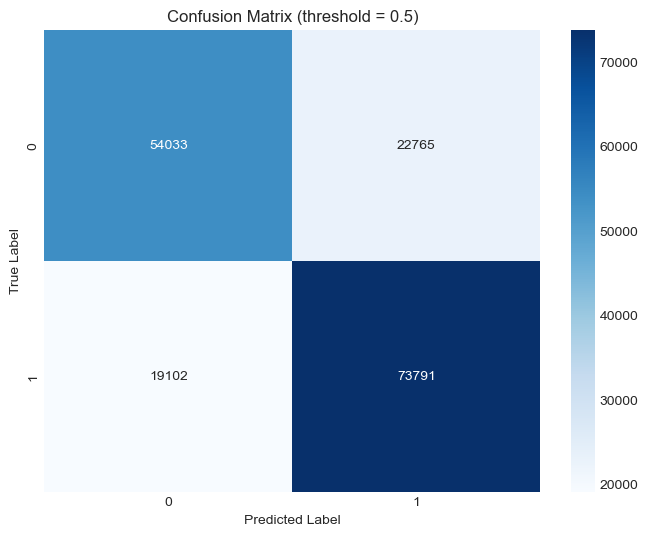

In [243]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Подбор порога классификации


ЗАВИСИМОСТЬ F-МЕРЫ ОТ ПОРОГА КЛАССИФИКАЦИИ:


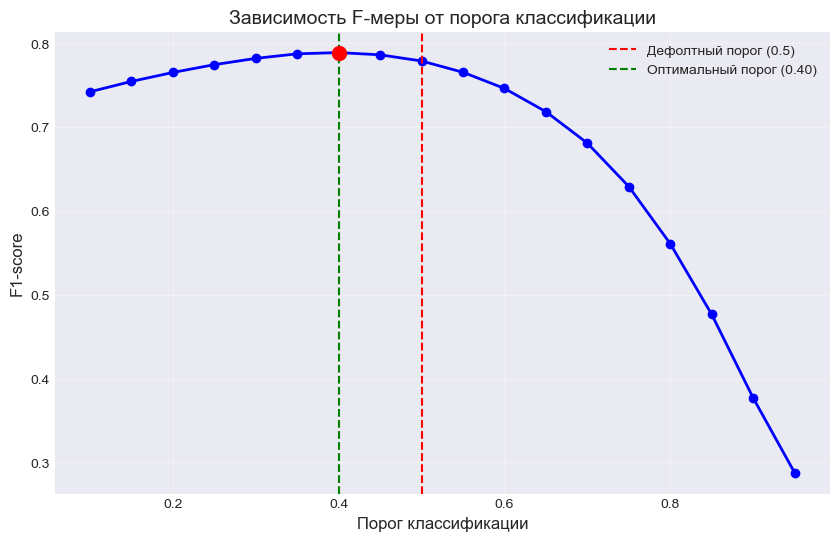


Оптимальный порог: 0.40
Максимальная F-мера: 0.7890

Метрики с оптимальным порогом:
              precision    recall  f1-score   support

           0       0.79      0.58      0.67     76798
           1       0.72      0.88      0.79     92893

    accuracy                           0.74    169691
   macro avg       0.76      0.73      0.73    169691
weighted avg       0.75      0.74      0.74    169691



In [244]:
# 7. Зависимость F-меры от порога классификации
print("\n" + "=" * 60)
print("ЗАВИСИМОСТЬ F-МЕРЫ ОТ ПОРОГА КЛАССИФИКАЦИИ:")
print("=" * 60)

thresholds = np.arange(0.1, 1.0, 0.05)
f1_scores = []
precisions = []
recalls = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold)
    f1_scores.append(f1)

# Построение графика зависимости F-меры от порога
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, 'b-', linewidth=2, marker='o')
plt.xlabel('Порог классификации', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.title('Зависимость F-меры от порога классификации', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='r', linestyle='--', label='Дефолтный порог (0.5)')

# Найдем оптимальный порог по F-мере
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

plt.axvline(x=optimal_threshold, color='g', linestyle='--', label=f'Оптимальный порог ({optimal_threshold:.2f})')
plt.scatter(optimal_threshold, optimal_f1, color='red', s=100, zorder=5)
plt.legend()
plt.show()

# 8. Метрики с оптимальным порогом
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print(f"\nОптимальный порог: {optimal_threshold:.2f}")
print(f"Максимальная F-мера: {optimal_f1:.4f}")
print("\nМетрики с оптимальным порогом:")
print(classification_report(y_test, y_pred_optimal))

## Важность признаков


ВАЖНОСТЬ ПРИЗНАКОВ:
           feature  importance
customerReturnRate   70.117826
 productReturnRate   11.411406
  salesPerCustomer    8.486922
       avgGbpPrice    2.220915
   salesPerProduct    1.909152
       productType    1.554335
         brandDesc    1.041722
   shippingCountry    0.980187
  avgDiscountValue    0.959967
            isMale    0.662751
       yearOfBirth    0.620459
           premier    0.034359

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:
Лучшая итерация: 999
Количество деревьев: 1000
Размер тренировочной выборки: 678763
Размер тестовой выборки: 169691
Баланс классов в целевой переменной:
  - Возврат (1): 54.74%
  - Нет возврата (0): 45.26%


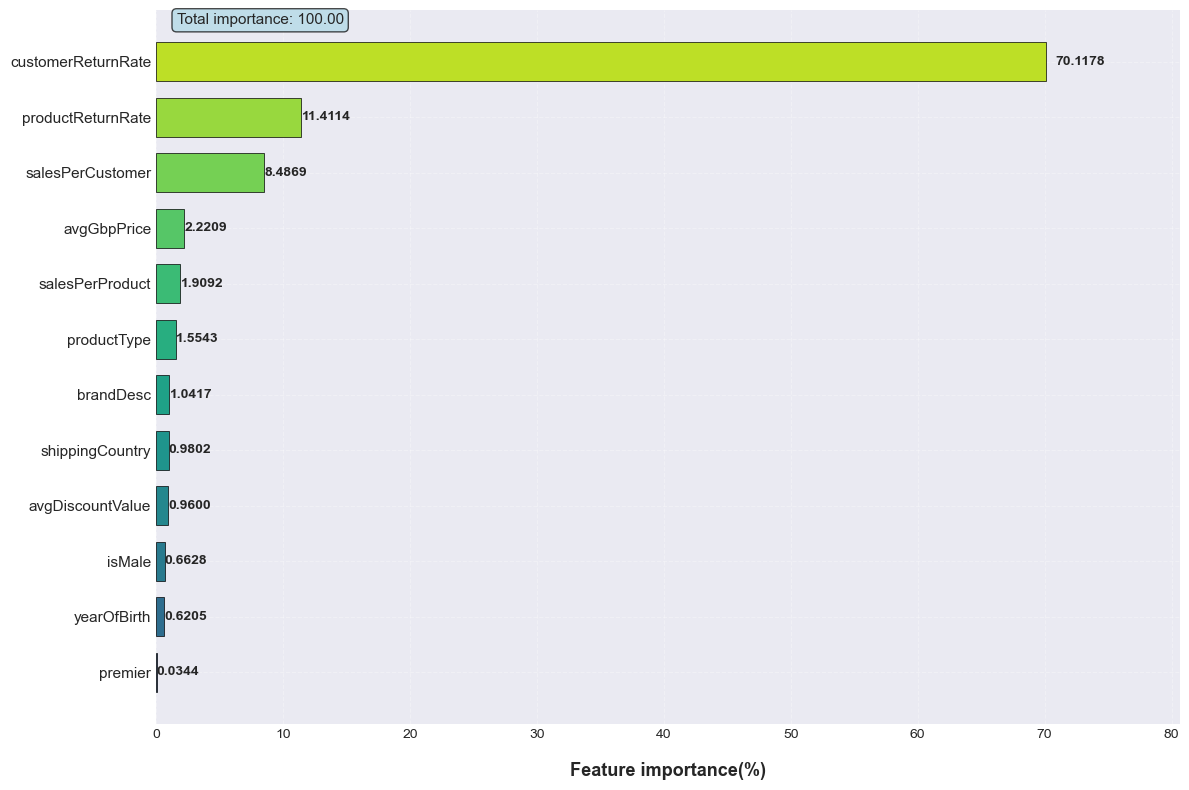

In [ ]:
# 9. Важность признаков
feature_importance = model.get_feature_importance()
feature_names = X.columns

# Создаем DataFrame для важности признаков
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n" + "=" * 60)
print("ВАЖНОСТЬ ПРИЗНАКОВ:")
print("=" * 60)
print(importance_df.to_string(index=False))


# 10. Дополнительная информация о модели
print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
print("=" * 60)
print(f"Лучшая итерация: {model.get_best_iteration()}")
print(f"Количество деревьев: {model.tree_count_}")
print(f"Размер тренировочной выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print("Баланс классов в целевой переменной:")
print(f"  - Возврат (1): {y.mean():.2%}")
print(f"  - Нет возврата (0): {(1 - y.mean()):.2%}")



# Установка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def plot_feature_importance_catboost(importance_df, top_n=20, figsize=(12, 8)):
    """
    Визуализация важности признаков для CatBoost модели
    
    Parameters:
    -----------
    importance_df : DataFrame
        DataFrame с колонками 'feature' и 'importance'
    top_n : int
        Количество топ-признаков для отображения
    figsize : tuple
        Размер фигуры
    """
    
    # Сортируем признаки по важности и берем top_n
    importance_sorted = importance_df.sort_values('importance', ascending=True).tail(top_n)
    
    # Создаем фигуру
    fig, ax = plt.subplots(figsize=figsize)
    
    # Создаем цветовую карту на основе важности
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_sorted)))
    
    # Создаем горизонтальный bar plot
    bars = ax.barh(range(len(importance_sorted)), 
                   importance_sorted['importance'], 
                   color=colors,
                   edgecolor='black',
                   linewidth=0.5,
                   height=0.7)
    
    # Добавляем значения важности на график
    for i, (bar, importance) in enumerate(zip(bars, importance_sorted['importance'])):
        width = bar.get_width()
        ax.text(width * 1.01, bar.get_y() + bar.get_height()/2,
                f'{importance:.4f}', 
                va='center', 
                ha='left',
                fontsize=10,
                fontweight='bold')
    
    # Настройка осей
    ax.set_yticks(range(len(importance_sorted)))
    ax.set_yticklabels(importance_sorted['feature'], fontsize=11)
    ax.set_xlabel('Feature importance(%)', fontsize=13, fontweight='bold', labelpad=15)
    #ax.set_title('Топ важных признаков CatBoost модели', 
    #             fontsize=16, 
    #             fontweight='bold', 
    #             pad=20)
    
    # Добавляем сетку
    ax.grid(True, alpha=0.3, linestyle='--', which='major')
    ax.set_axisbelow(True)
    
    # Добавляем суммарную важность в заголовок
    total_importance = importance_sorted['importance'].sum()
    ax.text(0.02, 0.98, 
            f'Total importance: {total_importance:.2f}',
            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    
    # Автоматическая настройка лимитов по x
    ax.set_xlim(0, importance_sorted['importance'].max() * 1.15)
    
    # Убираем верхнюю и правую границы
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    return fig, ax

# Альтернативный вариант с градиентной заливкой
def plot_feature_importance_gradient(importance_df, top_n=15, figsize=(14, 9)):
    """
    Градиентная визуализация важности признаков
    """
    
    # Сортируем признаки по важности
    importance_sorted = importance_df.sort_values('importance', ascending=False).head(top_n)
    
    # Создаем фигуру
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, 
                                    gridspec_kw={'width_ratios': [3, 1]})
    
    # Основной график с барами
    norm_importance = importance_sorted['importance'] / importance_sorted['importance'].max()
    colors = plt.cm.coolwarm(norm_importance)
    
    bars = ax1.barh(range(len(importance_sorted)), 
                    importance_sorted['importance'],
                    color=colors,
                    edgecolor='white',
                    linewidth=1.5,
                    height=0.8)
    
    # Добавляем значения
    for i, (bar, importance) in enumerate(zip(bars, importance_sorted['importance'])):
        ax1.text(bar.get_width() * 1.01, 
                bar.get_y() + bar.get_height()/2,
                f'{importance:.4f}',
                va='center',
                ha='left',
                fontsize=10)
    
    # Настройки основного графика
    ax1.set_yticks(range(len(importance_sorted)))
    ax1.set_yticklabels(importance_sorted['feature'], fontsize=11)
    ax1.set_xlabel('Важность', fontsize=12, fontweight='bold')
    ax1.set_title(f'Top-{top_n} features CatBoost', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    
    # Круговой график для распределения важности
    ax2.pie(importance_sorted['importance'], 
            labels=importance_sorted['feature'],
            colors=colors,
            startangle=90,
            wedgeprops=dict(width=0.3, edgecolor='w'))
    ax2.set_title('Распределение важности', fontsize=12, fontweight='bold')
    
    # Добавляем общую статистику
    stats_text = f'''Статистика важности:
    Всего признаков: {len(importance_df)}
    Показано: {top_n}
    Медиана: {importance_df['importance'].median():.4f}
    Максимум: {importance_df['importance'].max():.4f}'''
    
    fig.text(0.02, 0.02, stats_text, 
             fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    return fig, (ax1, ax2)

# Пример использования:
fig, ax = plot_feature_importance_catboost(importance_df, top_n=15)
plt.savefig('feature_importance_catboost.png', 
        dpi=300,  # высокое качество
        bbox_inches='tight',  # обрезать пустые поля
        facecolor='white',  # белый фон
        edgecolor='none')  # без границы
plt.show()

# Или для градиентного варианта:
# fig, axes = plot_feature_importance_gradient(importance_df, top_n=12)
# plt.show()

### Сохраним модель

In [159]:
model.save_model("catboost_model.json", format="json")

## Пробуем без признаков ReturnRate

Заметим по графику важности признаков, что модель производит классификацию, опираясь, в основном, всего на 2 признака: customerReturnRate и productReturnRate. Иными словами, модель "смотрит", как часто конкретный покупатель делает возвраты и как часто возвращается конкретный товар, и на основе этого делает прогноз. 

Интересно посмотреть, как изменится качество модели, если убрать данные признаки.

In [246]:
df = df_evt.merge(df_cus, how='inner', on='hash(customerId)').merge(df_prt, how='inner', on='hash(variantID)')

In [247]:
df.drop(columns=['hash(customerId)', 'hash(variantID)'], inplace=True)

In [248]:
df = df[['salesPerCustomer', 'salesPerProduct', 'yearOfBirth', 'isMale', 'shippingCountry', 'premier', 'productType', 'brandDesc', 'avgGbpPrice', 'avgDiscountValue', 'isReturned']]

In [249]:
# 1. Разделение на признаки и целевую переменную
X = df.drop('isReturned', axis=1)
y = df['isReturned']

categorical_features = ['shippingCountry', 'productType', 'brandDesc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

cat_features_indices = [X.columns.get_loc(col) for col in categorical_features]

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    cat_features=cat_features_indices,
    verbose=100,
    early_stopping_rounds=50
)

# Обучение модели
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=100
)

# 5. Прогнозы на тестовой выборке
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = model.predict(X_test)

# 6. Метрики с дефолтным порогом (0.5)
print("=" * 60)
print("МЕТРИКИ С ПОРОГОМ 0.5:")
print("=" * 60)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1_default = f1_score(y_test, y_pred_default)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"F1-score: {f1_default:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default))

0:	test: 0.6707906	best: 0.6707906 (0)	total: 293ms	remaining: 2m 26s
100:	test: 0.6969925	best: 0.6969925 (100)	total: 15.9s	remaining: 1m 2s
200:	test: 0.6993613	best: 0.6993613 (200)	total: 31.4s	remaining: 46.7s
300:	test: 0.7004809	best: 0.7004809 (300)	total: 49.3s	remaining: 32.6s
400:	test: 0.7011589	best: 0.7011589 (400)	total: 1m 7s	remaining: 16.8s
499:	test: 0.7015951	best: 0.7015951 (499)	total: 1m 26s	remaining: 0us

bestTest = 0.70159511
bestIteration = 499

МЕТРИКИ С ПОРОГОМ 0.5:
ROC-AUC: 0.7016
F1-score: 0.7026

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58     38399
           1       0.66      0.75      0.70     46447

    accuracy                           0.65     84846
   macro avg       0.65      0.64      0.64     84846
weighted avg       0.65      0.65      0.65     84846



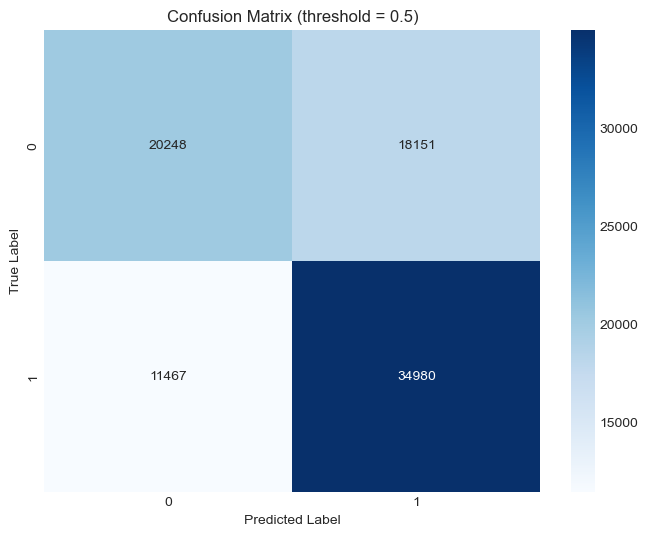

In [250]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


ЗАВИСИМОСТЬ F-МЕРЫ ОТ ПОРОГА КЛАССИФИКАЦИИ:


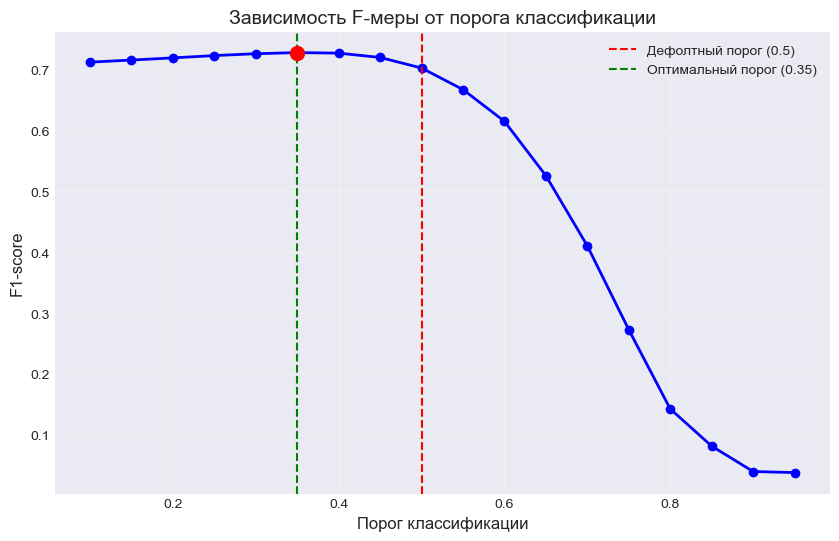


Оптимальный порог: 0.35
Максимальная F-мера: 0.7279

Метрики с оптимальным порогом:
              precision    recall  f1-score   support

           0       0.76      0.22      0.34     38399
           1       0.59      0.94      0.73     46447

    accuracy                           0.61     84846
   macro avg       0.68      0.58      0.53     84846
weighted avg       0.67      0.61      0.55     84846



In [251]:
# 7. Зависимость F-меры от порога классификации
print("\n" + "=" * 60)
print("ЗАВИСИМОСТЬ F-МЕРЫ ОТ ПОРОГА КЛАССИФИКАЦИИ:")
print("=" * 60)

thresholds = np.arange(0.1, 1.0, 0.05)
f1_scores = []
precisions = []
recalls = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold)
    f1_scores.append(f1)

# Построение графика зависимости F-меры от порога
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, 'b-', linewidth=2, marker='o')
plt.xlabel('Порог классификации', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.title('Зависимость F-меры от порога классификации', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='r', linestyle='--', label='Дефолтный порог (0.5)')

# Найдем оптимальный порог по F-мере
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

plt.axvline(x=optimal_threshold, color='g', linestyle='--', label=f'Оптимальный порог ({optimal_threshold:.2f})')
plt.scatter(optimal_threshold, optimal_f1, color='red', s=100, zorder=5)
plt.legend()
plt.show()

# 8. Метрики с оптимальным порогом
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print(f"\nОптимальный порог: {optimal_threshold:.2f}")
print(f"Максимальная F-мера: {optimal_f1:.4f}")
print("\nМетрики с оптимальным порогом:")
print(classification_report(y_test, y_pred_optimal))


ВАЖНОСТЬ ПРИЗНАКОВ:
         feature  importance
salesPerCustomer   46.392358
 shippingCountry   13.844226
     productType   12.449645
 salesPerProduct    9.881075
     avgGbpPrice    9.154584
       brandDesc    3.820514
     yearOfBirth    1.986068
avgDiscountValue    1.590998
          isMale    0.741458
         premier    0.139073


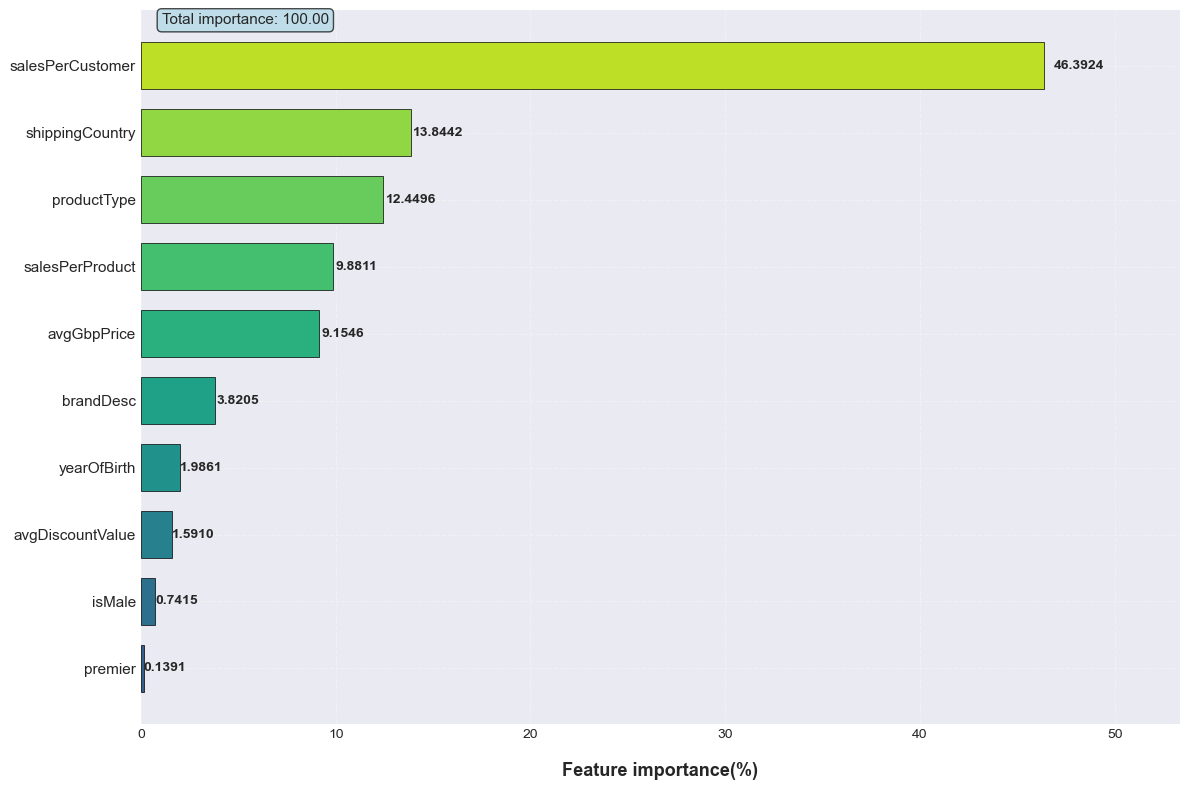


ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:
Лучшая итерация: 499
Количество деревьев: 500
Размер тренировочной выборки: 763608
Размер тестовой выборки: 84846
Баланс классов в целевой переменной:
  - Возврат (1): 54.74%
  - Нет возврата (0): 45.26%


In [ ]:
# 9. Важность признаков
feature_importance = model.get_feature_importance()
feature_names = X.columns

# Создаем DataFrame для важности признаков
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n" + "=" * 60)
print("ВАЖНОСТЬ ПРИЗНАКОВ:")
print("=" * 60)
print(importance_df.to_string(index=False))

# График важности признаков

# Установка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def plot_feature_importance_catboost(importance_df, top_n=20, figsize=(12, 8)):
    """
    Визуализация важности признаков для CatBoost модели
    
    Parameters:
    -----------
    importance_df : DataFrame
        DataFrame с колонками 'feature' и 'importance'
    top_n : int
        Количество топ-признаков для отображения
    figsize : tuple
        Размер фигуры
    """
    
    # Сортируем признаки по важности и берем top_n
    importance_sorted = importance_df.sort_values('importance', ascending=True).tail(top_n)
    
    # Создаем фигуру
    fig, ax = plt.subplots(figsize=figsize)
    
    # Создаем цветовую карту на основе важности
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_sorted)))
    
    # Создаем горизонтальный bar plot
    bars = ax.barh(range(len(importance_sorted)), 
                   importance_sorted['importance'], 
                   color=colors,
                   edgecolor='black',
                   linewidth=0.5,
                   height=0.7)
    
    # Добавляем значения важности на график
    for i, (bar, importance) in enumerate(zip(bars, importance_sorted['importance'])):
        width = bar.get_width()
        ax.text(width * 1.01, bar.get_y() + bar.get_height()/2,
                f'{importance:.4f}', 
                va='center', 
                ha='left',
                fontsize=10,
                fontweight='bold')
    
    # Настройка осей
    ax.set_yticks(range(len(importance_sorted)))
    ax.set_yticklabels(importance_sorted['feature'], fontsize=11)
    ax.set_xlabel('Feature importance(%)', fontsize=13, fontweight='bold', labelpad=15)
    #ax.set_title('Топ важных признаков CatBoost модели', 
    #             fontsize=16, 
    #             fontweight='bold', 
    #             pad=20)
    
    # Добавляем сетку
    ax.grid(True, alpha=0.3, linestyle='--', which='major')
    ax.set_axisbelow(True)
    
    # Добавляем суммарную важность в заголовок
    total_importance = importance_sorted['importance'].sum()
    ax.text(0.02, 0.98, 
            f'Total importance: {total_importance:.2f}',
            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    
    # Автоматическая настройка лимитов по x
    ax.set_xlim(0, importance_sorted['importance'].max() * 1.15)
    
    # Убираем верхнюю и правую границы
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    return fig, ax

# Альтернативный вариант с градиентной заливкой
# def plot_feature_importance_gradient(importance_df, top_n=15, figsize=(14, 9)):
#     """
#     Градиентная визуализация важности признаков
#     """
    
#     # Сортируем признаки по важности
#     importance_sorted = importance_df.sort_values('importance', ascending=False).head(top_n)
    
#     # Создаем фигуру
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, 
#                                     gridspec_kw={'width_ratios': [3, 1]})
    
#     # Основной график с барами
#     norm_importance = importance_sorted['importance'] / importance_sorted['importance'].max()
#     colors = plt.cm.coolwarm(norm_importance)
    
#     bars = ax1.barh(range(len(importance_sorted)), 
#                     importance_sorted['importance'],
#                     color=colors,
#                     edgecolor='white',
#                     linewidth=1.5,
#                     height=0.8)
    
#     # Добавляем значения
#     for i, (bar, importance) in enumerate(zip(bars, importance_sorted['importance'])):
#         ax1.text(bar.get_width() * 1.01, 
#                 bar.get_y() + bar.get_height()/2,
#                 f'{importance:.4f}',
#                 va='center',
#                 ha='left',
#                 fontsize=10)
    
#     # Настройки основного графика
#     ax1.set_yticks(range(len(importance_sorted)))
#     ax1.set_yticklabels(importance_sorted['feature'], fontsize=11)
#     ax1.set_xlabel('Важность', fontsize=12, fontweight='bold')
#     ax1.set_title(f'Top-{top_n} features CatBoost', fontsize=14, fontweight='bold')
#     ax1.invert_yaxis()
    
#     # Круговой график для распределения важности
#     ax2.pie(importance_sorted['importance'], 
#             labels=importance_sorted['feature'],
#             colors=colors,
#             startangle=90,
#             wedgeprops=dict(width=0.3, edgecolor='w'))
#     ax2.set_title('Распределение важности', fontsize=12, fontweight='bold')
    
#     # Добавляем общую статистику
#     stats_text = f'''Статистика важности:
#     Всего признаков: {len(importance_df)}
#     Показано: {top_n}
#     Медиана: {importance_df['importance'].median():.4f}
#     Максимум: {importance_df['importance'].max():.4f}'''
    
#     fig.text(0.02, 0.02, stats_text, 
#              fontsize=10, 
#              bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
#     plt.tight_layout()
#     return fig, (ax1, ax2)

# Пример использования:
fig, ax = plot_feature_importance_catboost(importance_df, top_n=15)
plt.savefig('feature_importance_reduced.png', 
        dpi=300,  # высокое качество
        bbox_inches='tight',  # обрезать пустые поля
        facecolor='white',  # белый фон
        edgecolor='none')  # без границы
plt.show()

# 10. Дополнительная информация о модели
print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
print("=" * 60)
print(f"Лучшая итерация: {model.get_best_iteration()}")
print(f"Количество деревьев: {model.tree_count_}")
print(f"Размер тренировочной выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print("Баланс классов в целевой переменной:")
print(f"  - Возврат (1): {y.mean():.2%}")
print(f"  - Нет возврата (0): {(1 - y.mean()):.2%}")

Наблюдается заметный спад в метриках качества модели - убранные нами признаки критически важны для качества классификации. 

В отсутсвии признаков customerReturnRate и productReturnRate наиболее важными становятся признаки **shippingCountry**, **productType** и **avgGbpPrice**.